# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


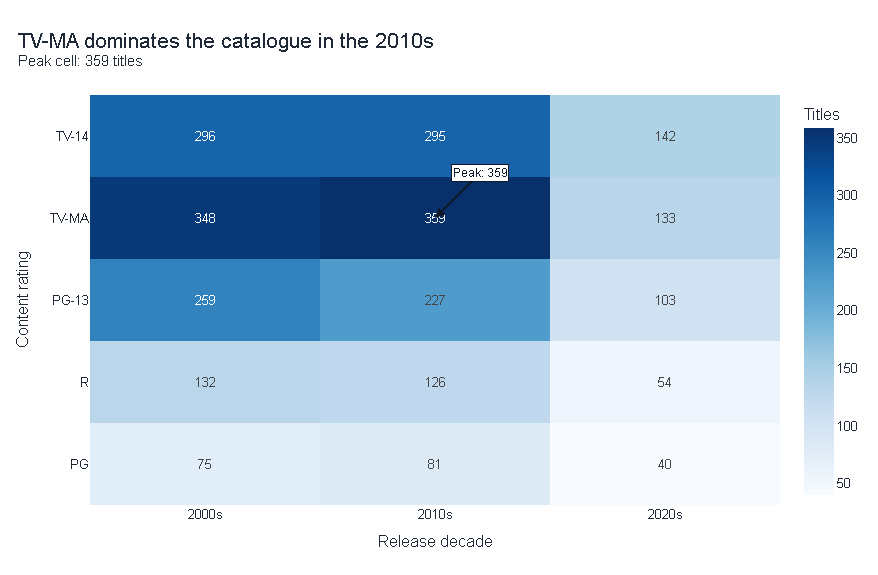

In [3]:
# Task 1 - Heatmap: content by rating and release decade

rating_order = ["TV-14", "TV-MA", "PG-13", "R", "PG"]

df_heatmap = df.copy()
df_heatmap["decade"] = (df_heatmap["release_year"] // 10 * 10).astype(str) + "s"

df_heatmap = df_heatmap[df_heatmap["rating"].isin(rating_order)]

heatmap_counts = (
    df_heatmap
    .groupby(["rating", "decade"])
    .size()
    .reset_index(name="title_count")
)

decade_order = sorted(
    heatmap_counts["decade"].unique(),
    key=lambda x: int(x.replace("s", ""))
)

heatmap_matrix = (
    heatmap_counts
    .pivot(index="rating", columns="decade", values="title_count")
    .reindex(index=rating_order, columns=decade_order)
    .fillna(0)
    .astype(int)
)

max_rating = heatmap_matrix.stack().idxmax()[0]
max_decade = heatmap_matrix.stack().idxmax()[1]
max_count = heatmap_matrix.loc[max_rating, max_decade]

try:
    fig = px.imshow(
        heatmap_matrix,
        text_auto=True,
        color_continuous_scale="Blues",
        aspect="auto",
        labels=dict(x="Release decade", y="Content rating", color="Titles"),
        title=(
            f"{max_rating} dominates the catalogue in the {max_decade}"
            f"<br><sup>Peak cell: {max_count} titles</sup>"
        )
    )
except TypeError:
    fig = px.imshow(
        heatmap_matrix,
        color_continuous_scale="Blues",
        aspect="auto",
        labels=dict(x="Release decade", y="Content rating", color="Titles"),
        title=(
            f"{max_rating} dominates the catalogue in the {max_decade}"
            f"<br><sup>Peak cell: {max_count} titles</sup>"
        )
    )
    fig.update_traces(
        text=heatmap_matrix.values,
        texttemplate="%{text}"
    )

fig.add_annotation(
    x=max_decade,
    y=max_rating,
    text=f"Peak: {max_count}",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#111827",
    ax=45,
    ay=-45,
    bgcolor="white",
    bordercolor="#111827",
    borderwidth=1,
    font=dict(color="#111827", size=12)
)

fig.update_layout(
    template="plotly_white",
    height=560,
    width=900,
    title=dict(x=0.02, xanchor="left", font=dict(size=21)),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=90, r=40, t=95, b=70)
)

fig.update_xaxes(side="bottom")
fig.update_yaxes(title="Content rating")

fig.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


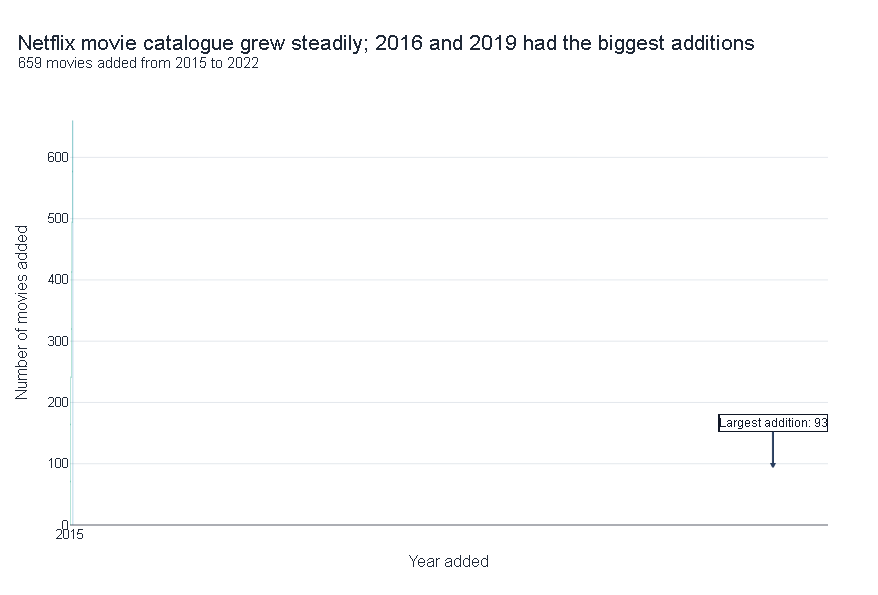

In [6]:
# Task 2 - Waterfall: Movie additions by year

df_waterfall = df.copy()
df_waterfall["added_year"] = pd.to_numeric(df_waterfall["added_year"], errors="coerce")

movie_yearly = (
    df_waterfall.loc[
        (df_waterfall["type"] == "Movie") &
        (df_waterfall["added_year"].between(2015, 2022))
    ]
    .groupby("added_year")
    .size()
    .reindex(range(2015, 2023), fill_value=0)
    .reset_index(name="additions")
)

movie_yearly["added_year"] = movie_yearly["added_year"].astype(int)

total_movies_added = int(movie_yearly["additions"].sum())
max_additions = int(movie_yearly["additions"].max())

peak_years = movie_yearly.loc[
    movie_yearly["additions"] == max_additions,
    "added_year"
].astype(str).tolist()

x_labels = movie_yearly["added_year"].astype(str).tolist() + ["Total"]
y_values = movie_yearly["additions"].tolist() + [total_movies_added]
measure_values = ["relative"] * len(movie_yearly) + ["total"]

fig = go.Figure(
    go.Waterfall(
        x=x_labels,
        y=y_values,
        measure=measure_values,
        text=[f"+{v}" for v in movie_yearly["additions"]] + [f"{total_movies_added}"],
        textposition="outside",
        connector=dict(line=dict(color="rgba(107, 114, 128, 0.45)", width=1.5)),
        increasing=dict(marker=dict(color="#009E73")),
        decreasing=dict(marker=dict(color="#D55E00")),
        totals=dict(marker=dict(color="#0072B2")),
        hovertemplate="<b>%{x}</b><br>Movies added: %{y}<extra></extra>"
    )
)

for year in peak_years:
    fig.add_annotation(
        x=year,
        y=max_additions,
        text=f"Largest addition: {max_additions}",
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-45,
        bgcolor="white",
        bordercolor="#111827",
        borderwidth=1,
        font=dict(color="#111827", size=12)
    )

peak_year_text = " and ".join(peak_years)

fig.update_layout(
    template="plotly_white",
    height=580,
    width=950,
    title=dict(
        text=(
            f"Netflix movie catalogue grew steadily; {peak_year_text} had the biggest additions"
            f"<br><sup>{total_movies_added} movies added from 2015 to 2022</sup>"
        ),
        x=0.02,
        xanchor="left",
        font=dict(size=21)
    ),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=70, r=50, t=100, b=70),
    showlegend=False
)

fig.update_xaxes(
    title="Year added",
    type="category",
    categoryorder="array",
    categoryarray=x_labels
)

fig.update_yaxes(
    title="Number of movies added",
    showgrid=True,
    gridcolor="rgba(148, 163, 184, 0.25)",
    zeroline=True,
    zerolinecolor="rgba(17, 24, 39, 0.35)"
)

fig.show()

## Key Insights

### Task 1: Content by Rating and Release Decade

The heatmap shows that Netflix catalogue content is concentrated most strongly in mature and teen-oriented ratings.

The largest cell is **TV-MA titles from the 2010s**, with **359 titles**. TV-MA is also very strong in the 2000s, showing that mature-audience content forms a major part of the catalogue.

TV-14 is also highly represented across the 2000s and 2010s, while PG, PG-13, and R appear in smaller but still meaningful volumes. Overall, the heatmap suggests that Netflix's catalogue is more heavily weighted toward adult and teen content than family-only content.

### Task 2: Movie Additions by Year

The waterfall chart shows steady movie catalogue growth from **2015 to 2022**.

Netflix added a total of **659 movies** during this period. The largest annual additions happened in **2016** and **2019**, with **93 movies** added in each year.

The growth pattern does not show one extreme spike. Instead, additions remain fairly consistent year by year, suggesting a sustained catalogue expansion strategy rather than a single unusual growth year.

### Overall Conclusion

The heatmap is best for comparing rating and decade combinations, while the waterfall chart is best for showing cumulative catalogue growth over time.

Together, the visuals show that Netflix's catalogue is strongly shaped by mature and teen content, while movie additions between 2015 and 2022 grew in a stable and consistent pattern.